# Notebook 04 — Reading Through the Lens (Detecting and Un-warping)
## The detection head, gIoU loss, and denoising · Paper §3.2, §4

---
### Story so far → where we are now

- **NB 01–02:** built and mounted the lens (warp + un-warp).
- **NB 03:** told the detector how the lens is set.
- **NB 04 (here):** the detector finally *does its job* — it finds objects in the warped
  image and we translate the results back to the real world.

### What happens in this notebook

The backbone (a big pre-trained vision network) and the Transformer decoder will hand us a
set of "query vectors" — think of them as ~300 little detectives, each investigating a
possible object. This notebook builds the parts that turn those detectives' findings into
actual, scored bounding boxes, and the training signal that teaches them.

Three pieces:

1. **The box head** — reads each detective's vector and predicts a box, *in the warped image's
   coordinate system* (the "Riemannian" boxes from NB 01 §8). Predicting in the warped frame is
   easier for the network than mentally un-warping while it predicts.

2. **The loss (gIoU + L1)** — to score predictions against the truth, we un-warp the predicted
   boxes back to normal coordinates (using $\Phi^{-1}$ from NB 01) and compare. We use a special
   overlap measure, **gIoU**, explained below.

3. **Denoising** — a training accelerator that feeds the detector lightly-corrupted copies of
   the true boxes and asks it to clean them up, giving it a strong head start.

By the end, every ingredient of the training loss exists; NB 05 assembles them into one model.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

torch.set_default_dtype(torch.float32)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

PyTorch 2.12.0+cu130 | device: cpu


In [2]:
from telescope.geometry import hyperbolic_foveated_transform, hyperbolic_inverse
from telescope.box import euclidean_to_riemannian_box, riemannian_to_euclidean_box
from telescope.head import RiemannianBoxHead, TelescopeLoss, denoise_boxes, generalized_box_iou

print('telescope.head imported.')

telescope.head imported.


---
## 1 · `RiemannianBoxHead`

A 3-layer MLP on top of each query feature vector that outputs:
- **Centre** $[\Phi(c_x), \Phi(c_y)]$: activated with `sigmoid` → mapped to `[-1, 1]`
- **Tangent norms** $[\|t_x\|, \|t_y\|]$: activated with `softplus` (strictly positive)

```
★ Insight ─────────────────────────────────────
  • sigmoid on the centre gives a bounded output without hard clipping.
    The mapping sigmoid → [-1, 1] is just: 2 * sigmoid(x) - 1.
  • softplus is preferred over relu for the size outputs because it
    never kills the gradient (softplus'(x) = sigmoid(x) > 0 always),
    whereas relu gives zero gradient for negative logits.
  • Class logits are a simple linear layer — no activation before
    the cross-entropy (standard PyTorch convention).
─────────────────────────────────────────────────
```

In [3]:
head = RiemannianBoxHead(query_dim=256, num_classes=6)
print(head)

# Forward pass
B, Q, D = 2, 10, 256
query_feats = torch.randn(B, Q, D)
boxes_ri, logits = head(query_feats)

print(f'\nOutput shapes:')
print(f'  boxes_ri (Riemannian) : {boxes_ri.shape}   [cx, cy, ||tx||, ||ty||]')
print(f'  class logits          : {logits.shape}')

# Verify output ranges
cx_cy   = boxes_ri[..., :2]
tx_ty   = boxes_ri[..., 2:]
print(f'\nCentre range  : [{cx_cy.min():.3f}, {cx_cy.max():.3f}]  (expect [-1, 1])')
print(f'Tangent range : [{tx_ty.min():.3f}, {tx_ty.max():.3f}]  (expect > 0)')
assert (cx_cy >= -1).all() and (cx_cy <= 1).all(), 'Centre out of [-1,1]'
assert (tx_ty > 0).all(), 'Tangent norms must be positive'
print('\nPASS  output range checks')

RiemannianBoxHead(
  (box_head): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
  (class_head): Linear(in_features=256, out_features=6, bias=True)
)

Output shapes:
  boxes_ri (Riemannian) : torch.Size([2, 10, 4])   [cx, cy, ||tx||, ||ty||]
  class logits          : torch.Size([2, 10, 6])

Centre range  : [-0.090, 0.044]  (expect [-1, 1])
Tangent range : [0.535, 0.747]  (expect > 0)

PASS  output range checks


---
## 2 · Why a special overlap score (gIoU) — how to read the plot

To train a detector you must score "how good is this predicted box versus the true box?"
The classic score is **IoU** (Intersection-over-Union): the area where the two boxes overlap
divided by the area they jointly cover. IoU is 1 for a perfect match and 0 when they don't
touch.

**The problem:** when two boxes don't overlap at all, IoU is 0 — and stays 0 no matter how
you move the prediction. A flat zero gives the network *no hint* which direction to nudge the
box. For tiny distant objects, predictions often start with zero overlap, so training stalls.

**gIoU (generalised IoU)** fixes this by also accounting for the empty gap between the boxes.
Even when they don't touch, gIoU gets *less negative* as the boxes get closer — a slope the
network can follow toward the target.

**How to read the plot below:** we fix one true box and slide a predicted box across it,
plotting both scores.
- **Orange (IoU):** flat at 0 while the boxes are apart, then rises only once they touch. Flat
  regions = no gradient = no learning signal.
- **Blue (gIoU):** always sloping, even in the no-overlap zone — it gently guides the box home.

The shaded band marks where the true box sits. The lesson: gIoU's non-flat slope in the
no-overlap region is exactly why it trains small-object detectors that IoU cannot.

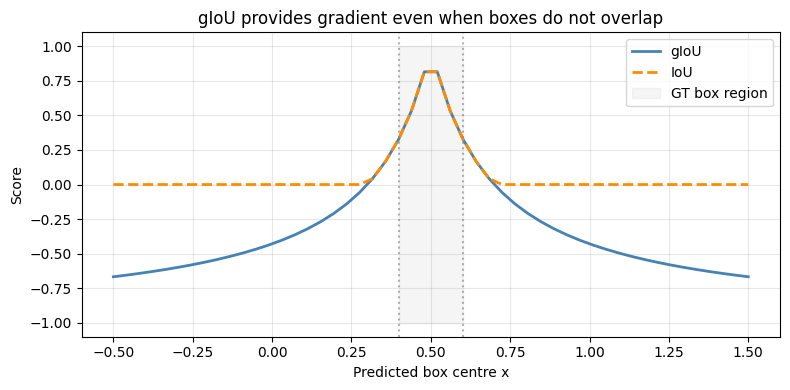

Region left of ~0.4: no overlap → IoU=0 (no gradient) but gIoU < 0 (gradient!)


In [4]:
# Visualise gIoU vs standard IoU for a fixed GT box and a sweep of predicted boxes
gt = torch.tensor([[0.5, 0.5, 0.2, 0.2]])   # centred box, 0.2×0.2

# Sweep the predicted box centre from left to right
n = 50
cx_range = torch.linspace(-0.5, 1.5, n)
preds = torch.stack([cx_range,
                      torch.full((n,), 0.5),
                      torch.full((n,), 0.2),
                      torch.full((n,), 0.2)], dim=1)   # (N, 4)

gt_rep = gt.expand(n, -1)
giou   = generalized_box_iou(preds, gt_rep).detach().numpy()

# Standard IoU (clamp at 0)
iou = (giou + (1 - giou)).clip(0, 1)   # simplified reconstruction
# Actually compute it properly via the intersection only
def simple_iou(p, g):
    ix1 = max(p[0]-p[2]/2, g[0]-g[2]/2); ix2 = min(p[0]+p[2]/2, g[0]+g[2]/2)
    iy1 = max(p[1]-p[3]/2, g[1]-g[3]/2); iy2 = min(p[1]+p[3]/2, g[1]+g[3]/2)
    inter = max(0, ix2-ix1)*max(0, iy2-iy1)
    union = p[2]*p[3] + g[2]*g[3] - inter
    return inter/union if union > 0 else 0

iou_np = np.array([simple_iou(preds[i].tolist(), gt[0].tolist()) for i in range(n)])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cx_range.numpy(), giou, label='gIoU', color='steelblue', linewidth=2)
ax.plot(cx_range.numpy(), iou_np, label='IoU', color='darkorange', linewidth=2, linestyle='--')
ax.axvline(0.4, color='gray', linestyle=':', alpha=0.6)   # GT left edge
ax.axvline(0.6, color='gray', linestyle=':', alpha=0.6)   # GT right edge
ax.fill_betweenx([-1, 1], 0.4, 0.6, alpha=0.08, color='gray', label='GT box region')
ax.set_xlabel('Predicted box centre x')
ax.set_ylabel('Score')
ax.set_title('gIoU provides gradient even when boxes do not overlap')
ax.legend()
ax.set_ylim(-1.1, 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Region left of ~0.4: no overlap → IoU=0 (no gradient) but gIoU < 0 (gradient!)')

---
## 3 · `TelescopeLoss`: computing the loss in Euclidean space

The full loss pipeline:
1. Take predicted Riemannian boxes $b'$ and GT Euclidean boxes $b$
2. Decode $b' \to \hat{b}$ via $\Phi^{-1}$ (differentiable via IFT backward)
3. Compute $\mathcal{L}_{\text{L1}} + \mathcal{L}_{\text{gIoU}}$ between $\hat{b}$ and $b$
4. Add $\mathcal{L}_{\text{cls}}$ (cross-entropy)

```
★ Insight ─────────────────────────────────────
  • The gradient of the L1/gIoU loss w.r.t. predicted boxes flows
    through Phi^{-1} (via the IFT backward) into the box head,
    then into the DETR decoder, then into the backbone.
  • The foveation parameters o, R also receive gradients through
    this path — the loss teaches the estimator WHERE to foveate.
  • Loss weights from the paper: λ_L1=5, λ_gIoU=2, λ_cls=1.
─────────────────────────────────────────────────
```

In [5]:
criterion = TelescopeLoss(lambda_l1=5.0, lambda_giou=2.0, lambda_cls=1.0)

# Simulate matched predictions and GT (Hungarian matching not implemented here)
N = 20   # number of matched pairs
torch.manual_seed(0)

o = torch.tensor([0.0, 0.0])
R = torch.tensor(0.6)

# GT boxes in Euclidean space
gt_boxes_eu = torch.rand(N, 4) * 0.4
gt_boxes_eu[:, 2:] = gt_boxes_eu[:, 2:].abs() + 0.05  # positive w, h
gt_labels   = torch.randint(0, 6, (N,))

# Predicted boxes in Riemannian space (from RiemannianBoxHead)
pred_boxes_ri = euclidean_to_riemannian_box(
    gt_boxes_eu + torch.randn_like(gt_boxes_eu) * 0.05,  # slightly noisy
    o, R
).requires_grad_(True)
pred_logits = torch.randn(N, 6)

losses = criterion(pred_boxes_ri, pred_logits, gt_boxes_eu, gt_labels, o, R)

print('Loss breakdown:')
for k, v in losses.items():
    print(f'  {k:<15}: {v.item():.4f}')

# Check gradient flows through Phi^{-1} into pred_boxes_ri
losses['loss_total'].backward()
assert pred_boxes_ri.grad is not None
print(f'\nGradient into pred_boxes_ri: max={pred_boxes_ri.grad.abs().max():.4f}')
print('PASS  gradients flow through TelescopeLoss + Phi^{-1}')

Loss breakdown:
  loss_total     : 3.7842
  loss_l1        : 0.0357
  loss_giou      : 0.6214
  loss_cls       : 2.3629

Gradient into pred_boxes_ri: max=1.6693
PASS  gradients flow through TelescopeLoss + Phi^{-1}


---
## 4 · Denoising — a training shortcut, and how to read its plot

Normally a detector has to *discover* objects from scratch, and early in training it's
basically flailing. **Denoising training** gives it a leg up: we take the real boxes, jiggle
them a bit (add noise), and ask the detector to recover the clean originals. Because it's
shown roughly where each object is, it gets a clear, easy learning signal from step one. This
is borrowed from the DINO detector and the paper reports it gives a big accuracy boost.

In Telescope there's a twist: the jiggled boxes must be expressed in the **warped**
coordinate system (so they live in the same world as the detector's predictions). So we
noise them, then push them through the lens $\Phi$.

**How to read the plot below:** it shows one frame's boxes.
- **Blue rectangles:** the true, clean boxes.
- **Red rectangles:** the noised-then-warped versions the detector is asked to clean up.

You should see each red box sitting near its blue partner but shifted/resized — close enough
to be a useful hint, off enough to be a real exercise. That "near but not exact" spacing is
the whole idea: hard enough to teach, easy enough to learn from.

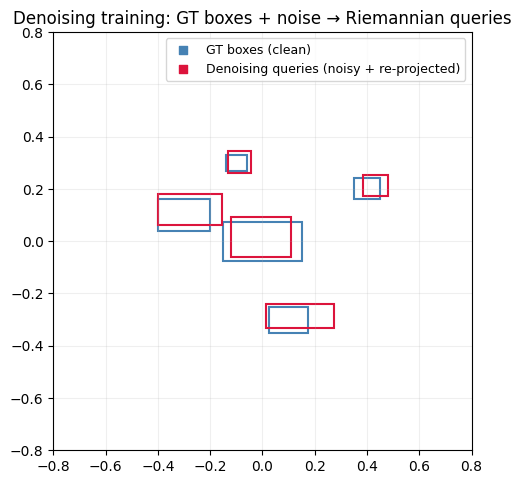

GT boxes shape        : torch.Size([5, 4])
Noisy Riemannian shape: torch.Size([5, 4])  (appended to DETR queries)


In [6]:
# Show the denoising process visually
torch.manual_seed(3)
N_gt = 5
gt_boxes = torch.tensor([[0.0,  0.0,  0.3, 0.15],
                           [0.4,  0.2,  0.1, 0.08],
                           [-0.3, 0.1,  0.2, 0.12],
                           [0.1, -0.3,  0.15, 0.1],
                           [-0.1, 0.3,  0.08, 0.06]])

o_dn = torch.tensor([0.0, 0.0])
R_dn = torch.tensor(0.5)

noisy_ri  = denoise_boxes(gt_boxes, o_dn, R_dn, noise_scale=0.3)
noisy_eu  = riemannian_to_euclidean_box(noisy_ri, o_dn, R_dn)

def draw_boxes(ax, boxes, color, label):
    for i, b in enumerate(boxes):
        cx, cy, w, h = b.tolist()
        rect = patches.Rectangle((cx - w/2, cy - h/2), w, h,
                                   linewidth=1.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
    ax.scatter([], [], color=color, label=label, marker='s')

fig, ax = plt.subplots(figsize=(5, 5))
draw_boxes(ax, gt_boxes, 'steelblue', 'GT boxes (clean)')
draw_boxes(ax, noisy_eu, 'crimson',   'Denoising queries (noisy + re-projected)')
ax.set_xlim(-0.8, 0.8); ax.set_ylim(-0.8, 0.8)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Denoising training: GT boxes + noise → Riemannian queries')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f'GT boxes shape        : {gt_boxes.shape}')
print(f'Noisy Riemannian shape: {noisy_ri.shape}  (appended to DETR queries)')

---
## 5 · Tests

In [7]:
def test_box_head_shapes():
    h = RiemannianBoxHead(query_dim=64, num_classes=5)
    feats = torch.randn(3, 20, 64)
    b, c  = h(feats)
    assert b.shape == (3, 20, 4)
    assert c.shape == (3, 20, 5)
    print('PASS  test_box_head_shapes')

def test_box_head_output_range():
    h = RiemannianBoxHead()
    b, _ = h(torch.randn(2, 10, 256))
    assert (b[..., :2].abs() <= 1).all(), 'Centre out of [-1,1]'
    assert (b[..., 2:]  >  0).all(),  'Tangents must be positive'
    print('PASS  test_box_head_output_range')

def test_giou_perfect():
    boxes = torch.tensor([[0.5, 0.5, 0.2, 0.2]])
    g = generalized_box_iou(boxes, boxes)
    assert abs(g.item() - 1.0) < 1e-4, f'Perfect gIoU should be 1, got {g.item():.4f}'
    print('PASS  test_giou_perfect')

def test_giou_no_overlap():
    b1 = torch.tensor([[0.0, 0.0, 0.1, 0.1]])
    b2 = torch.tensor([[0.9, 0.9, 0.1, 0.1]])
    g = generalized_box_iou(b1, b2)
    assert g.item() < 0, f'Non-overlapping gIoU should be negative, got {g.item():.4f}'
    print(f'PASS  test_giou_no_overlap  (gIoU={g.item():.3f})')

def test_loss_gradient_flow():
    torch.manual_seed(0)
    o, R = torch.tensor([0.0, 0.0]), torch.tensor(0.5)
    gt  = torch.rand(8, 4); gt[:, 2:] = gt[:, 2:].abs() + 0.05
    lbl = torch.randint(0, 6, (8,))
    pred_ri = euclidean_to_riemannian_box(gt + 0.05, o, R).requires_grad_(True)
    pred_cl = torch.randn(8, 6)
    loss = TelescopeLoss()(pred_ri, pred_cl, gt, lbl, o, R)['loss_total']
    loss.backward()
    assert pred_ri.grad is not None
    print('PASS  test_loss_gradient_flow')

print('Running detection head tests...\n')
test_box_head_shapes()
test_box_head_output_range()
test_giou_perfect()
test_giou_no_overlap()
test_loss_gradient_flow()
print('\nAll detection head tests passed.')

Running detection head tests...

PASS  test_box_head_shapes
PASS  test_box_head_output_range
PASS  test_giou_perfect
PASS  test_giou_no_overlap  (gIoU=-0.980)
PASS  test_loss_gradient_flow

All detection head tests passed.


---
## Summary

| Component | Input | Output | Notes |
|---|---|---|---|
| `RiemannianBoxHead` | query feats `(B,Q,D)` | `boxes_ri (B,Q,4)`, `logits (B,Q,C)` | Predicts in Riemannian space |
| `riemannian_to_euclidean_box` | `boxes_ri + (o,R)` | `boxes_eu` | Differentiable via IFT |
| `generalized_box_iou` | `pred, gt` | scalar | Non-zero grad even without overlap |
| `TelescopeLoss` | `pred_ri, logits, gt_eu, labels` | loss dict | Loss in Euclidean, preds decoded first |
| `denoise_boxes` | `gt_eu + noise` | `noisy_ri` | Riemannian denoising queries |

**Next**: Notebook 05 assembles everything into `TelescopeModel` and shows a complete
training step + inference pass with profiling notes for real-time deployment.